# Capstone Project: Предсказание низких оценок заказов на маркетплейсе Olist

## Цель проекта

Данный проект анализирует данные бразильского маркетплейса Olist (2016–2018 гг.) с целью выявить, какие характеристики заказа (сроки доставки, сумма покупки, способ оплаты, количество и репутация продавцов, состав товаров) связаны с низкой оценкой клиента (1–2 звезды из 5).

Итоговая задача сформулирована как **задача бинарной классификации**: предсказать, оставит ли клиент негативный отзыв (1–2 звезды) на основе характеристик заказа.

## Структура проекта

1. Загрузка библиотек
2. Загрузка файлов
3. Предварительная проверка данных
4. Создание базы данных (SQL)
5. EDA
6. Бинаризация целевой переменной
7. Обучение и сравнение моделей классификации (Logistic Regression, Random Forest)
8. Итоговые выводы и рекомендации

## Датасет

[Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). Содержит 9 связанных таблиц, содержащих данные о заказах, товарах, продавцах, платежах, доставке и отзывах клиентов.


## 1. Загрузка библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns

## 2. Загрузка файлов

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')


## 3. Предварительная проверка данных

### 3.1. Customers

In [3]:
customers.sample(5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
80395,b4c66ce8761acbc57160f0226e108861,d6ec09fb63945811040991774f053b83,87704,paranavai,PR
32196,7c6be5f52c68fffa86b02b20a8df80cb,3ba56ae6f3c98bebc9c5501fbd4ff3cd,22060,rio de janeiro,RJ
82591,a3d5aec988dc5a87e55667afa07191f8,d8426d1422ef6070ff3c146588281d7a,22750,rio de janeiro,RJ
86044,12388b49e68e75381131ee52c3b990de,abfe2e8ef4cf3bc2ad51b5f233634bcb,3535,sao paulo,SP
61310,d961229a6b7725cf493af5726e6453ad,f0ec6a441b2ad8daa1bb65b446bdb759,29101,vila velha,ES


In [4]:
customers.shape


(99441, 5)

In [5]:
customers.duplicated().sum()

np.int64(0)

In [6]:
customers.isnull().sum()


,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [7]:
customers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [8]:
# сравниваем число заказов (customer_id) и число уникальных людей (customer_unique_id)
print(f'Заказов: {customers['customer_id'].nunique()}')
print(f'Уникальных покупателей: {customers['customer_unique_id'].nunique()}')


Заказов: 99441
Уникальных покупателей: 96096


In [9]:
# сколько заказов сделал каждый уникальный покупатель
orders_per_customer = customers['customer_unique_id'].value_counts()
# покупатели с более чем одним заказом = повторные клиенты
returning_customers = (orders_per_customer > 1).sum()
print(f'Покупателей с более чем 1 заказом: {returning_customers}')
print(f'Из них процент от всех уникальных покупателей: {returning_customers / customers["customer_unique_id"].nunique() * 100:.2f}%')


Покупателей с более чем 1 заказом: 2997
Из них процент от всех уникальных покупателей: 3.12%


In [10]:
customers['customer_city'].value_counts()


,count
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
...,...
olhos d'agua,1
pacotuba,1
sao sebastiao do paraiba,1


In [11]:
customers['customer_state'].value_counts()


,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


**Вывод:** 99 441 строка, дублей и пропусков нет. `customer_id` уникален для каждого заказа, `customer_unique_id` уникален для реального человека: повторных покупателей всего 3.12% (2997 из 96 096). Больше всего клиентов из Sao Paolo (42%).

### 3.2. Geolocation

In [12]:
geolocation.sample(5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
146276,5846,-23.658831,-46.745272,sao paulo,SP
732485,58410,-7.244814,-35.882655,campina grande,PB
33771,2680,-23.450797,-46.673849,sao paulo,SP
446359,22291,-22.818595,-43.273225,rio de janeiro,RJ
228065,9370,-23.671603,-46.466365,maua,SP


In [13]:
geolocation.shape


(1000163, 5)

In [14]:
geolocation.duplicated().sum()


np.int64(261831)

In [15]:
geolocation.isnull().sum()


,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [16]:
geolocation.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


**Вывод:** 1 000 163 строки, пропусков нет, но обнаружено 261 831 дублирующихся строк (почтовый индекс). Таблица не используется в финальной таблице `features`.

### 3.3. Order Items

In [17]:
order_items.sample(5)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
99043,e0be387e4482cc1e135c5ffe3d896885,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-02 10:31:22,49.90,13.37
91423,cf71b9b6b7ed12d72f541b0420023f19,1,2b4609f8948be18874494203496bc318,cc419e0650a3c5ba77189a1882b7556a,2018-05-15 02:57:52,79.99,10.94
24916,38bcb524e1c38c2c1b60600a80fc8999,1,680cc8535be7cc69544238c1d6a83fe8,48efc9d94a9834137efd9ea76b065a38,2017-01-09 12:06:36,2.90,8.72
22562,337ace5c193fb745fca018fd1e542c9c,2,951e2998189b05082eab2080036b135b,ea8482cd71df3c1969d7b9473ff13abc,2018-02-14 01:49:44,24.99,17.63
67695,9acd35e199ceebf9f6fcf287fcc96050,1,4534bceddbf90ce5876ec482cc5c74d2,d91fb3b7d041e83b64a00a3edfb37e4f,2018-07-23 15:41:36,16.30,18.23


In [18]:
order_items.shape


(112650, 7)

In [19]:
order_items.duplicated().sum()


np.int64(0)

In [20]:
order_items.isnull().sum()


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [21]:
order_items[['price', 'freight_value']].describe()


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [22]:
order_items.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


**Вывод:** 112 650 строк, дублей и пропусков нет. Цена товара (`price`) в среднем 120 BLR, разброс большой и присутствуют выбросы, которые учтены при интерпретации графиков.

### 3.4. Order Payments

In [23]:
order_payments.sample(5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
33030,00611822267e76e0055c25c18506f06e,1,credit_card,3,180.21
99550,1c2fb7f84aa77300fcb6b698481c1e2e,1,credit_card,6,61.33
101707,b084a8f61aa45461c76604d752a993f8,1,boleto,1,104.37
21344,e1d4d1e4e8f00e0b9ac69e656d7f2db0,1,boleto,1,202.13
26555,287f07f2662d6fece557157bb5f87fd4,1,boleto,1,31.75


In [24]:
order_payments.shape


(103886, 5)

In [25]:
order_payments.duplicated().sum()


np.int64(0)

In [26]:
order_payments.isnull().sum()


,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [27]:
order_payments[['payment_value', 'payment_installments']].describe()


,payment_value,payment_installments
count,103886.000000,103886.000000
mean,154.100380,2.853349
std,217.494064,2.687051
min,0.000000,0.000000
25%,56.790000,1.000000
50%,100.000000,1.000000
75%,171.837500,4.000000
max,13664.080000,24.000000


In [28]:
order_payments.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


**Вывод:** 103 886 строк, дублей и пропусков нет. Сумма оплаты в среднем 154 BLR, рассрочка — в среднем 3 платежа. Один заказ может быть оплачен частями несколькими способами, поэтому при построении признаков потребуется суммирование на уровне заказа.

### 3.5. Order Reviews

In [29]:
order_reviews.sample(5)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
70012,3406c4e7a645428a47f5f99578e36138,47aa0308326d0c781ffa998ee36dc409,5,NaN,NaN,2018-06-07 00:00:00,2018-06-08 00:44:40
6345,19cab11455aa9f57d98e4a9eb4c261c5,66a5c9d33ec9b0db1d894e4812a0f941,5,NaN,Produto ótimo chegou antes do prazo eu recomendo,2017-04-05 00:00:00,2017-04-07 10:31:47
43511,45492b637a77865609f86bb4b99ed6d9,2a680095a7549ad07085fb6863f91316,5,NaN,NaN,2017-11-25 00:00:00,2017-11-27 19:20:29
66880,f65b0760cc5edf530d45dc416949ad60,c35f0be8d0dc1e48ed297f8ea0f44f26,5,NaN,NaN,2018-06-06 00:00:00,2018-06-06 20:14:56
17200,903a9a5d11b004edef65912383f1dd59,8a690db6867c58d3ed896a9a2127746b,5,NaN,NaN,2017-11-07 00:00:00,2017-11-10 11:49:49


In [30]:
order_reviews.shape


(99224, 7)

In [31]:
order_reviews.duplicated().sum()


np.int64(0)

In [32]:
order_reviews.isnull().sum()


,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [33]:
# проверяем заказы с несколькими отзывами (дубли по order_id)
print(f'Всего отзывов: {len(order_reviews)}')
print(f'Уникальных отзывов: {order_reviews['order_id'].nunique()}')
print(f'Дублирующихся отзывов: {len(order_reviews)-order_reviews['order_id'].nunique()}')


Всего отзывов: 99224
Уникальных отзывов: 98673
Дублирующихся отзывов: 551


In [34]:
order_reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


**Вывод:** 99 224 строки, пропусков в оценке нет (только в необязательных текстовых полях). Обнаружено **551 заказ с несколькими отзывами** (99 224 строки vs 98 673 уникальных `order_id`).

### 3.6. Orders

In [35]:
orders.sample(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
87698,7604b2e3523cee6efa15d486cddf96c4,7cd513bafb9ddd55a2777c37cf1a7d6f,delivered,2018-04-30 17:09:56,2018-05-01 02:38:31,2018-05-02 09:01:00,2018-05-07 22:03:53,2018-05-23 00:00:00
66319,4d3e60db45d11fb272ff7586b54b3f73,70d98c841b3004427e66e41bd2ace052,delivered,2018-02-07 09:50:16,2018-02-07 10:10:10,2018-02-08 22:47:37,2018-02-21 23:53:30,2018-03-07 00:00:00
3350,8a9b30ac80da3860f049247b7464596f,8e150843c1138147cf8ea7253de0319d,delivered,2018-02-08 08:46:56,2018-02-08 09:10:36,2018-02-15 20:23:26,2018-02-16 20:14:59,2018-02-26 00:00:00
11313,58ab53aab8ecabe6b411fa69f97b8be9,a6aa9543426b2f37964954cfc9ee474f,delivered,2018-06-07 20:45:20,2018-06-07 21:36:04,2018-06-08 14:18:00,2018-06-21 01:06:31,2018-07-04 00:00:00
30215,f8d1f0c2928f268becf4f82b181295c8,2c1234b6bbd4728d2836bfac2c52d1c8,delivered,2018-07-01 20:55:05,2018-07-01 21:10:12,2018-07-03 13:56:00,2018-07-10 12:27:38,2018-07-20 00:00:00


In [36]:
orders.shape


(99441, 8)

In [37]:
orders.duplicated().sum()


np.int64(0)

In [38]:
orders.isnull().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [39]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [40]:
# datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])


In [41]:
# диапазон дат заказов (с какого по какое число собраны данные)
pd.to_datetime(orders['order_purchase_timestamp']).describe()


,order_purchase_timestamp
count,99441
mean,2017-12-31 08:43:12.776581120
min,2016-09-04 21:15:19
25%,2017-09-12 14:46:19
50%,2018-01-18 23:04:36
75%,2018-05-04 15:42:16
max,2018-10-17 17:30:18


In [42]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](3), object(5)
memory usage: 6.1+ MB


**Вывод:** 99 441 строка, дублей нет. Есть пропуски в датах (`order_approved_at` — 160, `order_delivered_carrier_date` — 1783, `order_delivered_customer_date` — 2965), скорее всего эти заказы не были доставлены.

### 3.7. Products

In [43]:
products.sample(5)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
7483,0ca455b3fae1a463c84420392d655ab9,fashion_bolsas_e_acessorios,28.0,807.0,1.0,100.0,16.0,5.0,16.0
29570,24e8c79f39c68fbdbd57a5813ae72b94,relogios_presentes,22.0,852.0,1.0,225.0,19.0,12.0,15.0
25446,3b30fb3ac17cda9e7e5b5112c692f665,cool_stuff,54.0,1704.0,1.0,2400.0,62.0,7.0,35.0
10582,25184d12546e74ab8843112abca3f1d6,malas_acessorios,59.0,1616.0,5.0,950.0,27.0,10.0,28.0
412,2068e3435a38f6a3cc95ba89a96378ab,automotivo,58.0,894.0,1.0,3300.0,35.0,20.0,20.0


In [44]:
products.shape


(32951, 9)

In [45]:
products.duplicated().sum()


np.int64(0)

In [46]:
products.isnull().sum()


,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [47]:
products[['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']].describe()


,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.000000,32949.000000,32949.000000,32949.000000
mean,2276.472488,30.815078,16.937661,23.196728
std,4282.038731,16.914458,13.637554,12.079047
min,0.000000,7.000000,2.000000,6.000000
25%,300.000000,18.000000,8.000000,15.000000
50%,700.000000,25.000000,13.000000,20.000000
75%,1900.000000,38.000000,21.000000,30.000000
max,40425.000000,105.000000,105.000000,118.000000


In [48]:
products.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Вывод:** 32 951 строка, дублей нет. 610 товаров (1.9%) без указанной категории и названия, 2 товара без веса/габаритов. Это незначительная доля и на построение основных признаков не влияет.

### 3.8. Sellers



In [49]:
sellers.sample(5)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
115,0c8380b62e38e8a1e6adbeba7eb9688c,37410,tres coracoes,MG
2381,365e445f796710c3431557e85caa25db,4083,sao paulo,SP
1930,06a2c3af7b3aee5d69171b0e14f0ee87,65072,sao luis,MA
1173,6c9875b2f94ba781186f0c1aed8d1687,17380,brotas,SP
34,9c690ceacd5c66731bf443ea810195cb,37650,camanducaia,MG


In [50]:
sellers.shape


(3095, 4)

In [51]:
sellers.duplicated().sum()


np.int64(0)

In [52]:
sellers.isnull().sum()


,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [53]:
sellers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


**Вывод:** 3095 строк, дублей и пропусков нет. Таблица чистая, используется для подсчёта количества продавцов и их репутации на уровне заказа.

### 3.9. Category Translation

In [54]:
category_translation.sample(5)


,product_category_name,product_category_name_english
4,moveis_decoracao,furniture_decor
7,utilidades_domesticas,housewares
9,relogios_presentes,watches_gifts
65,dvds_blu_ray,dvds_blu_ray
11,bebes,baby


In [55]:
category_translation.shape


(71, 2)

In [56]:
category_translation.duplicated().sum()


np.int64(0)

In [57]:
category_translation.isnull().sum()


,0
product_category_name,0
product_category_name_english,0


In [58]:
category_translation.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


**Вывод:** 71 строка переводов названий категорий с португальского на английский. Не используется в финальной таблице `features`.

### 4. Создание базы данных и SQL

#### 4.1 Схема связей

orders.customer_id → customers

order_items.order_id, order_payments.order_id, order_reviews.order_id → orders

order_items.product_id → products

order_items.seller_id → sellers

In [59]:
# создаём файл базы данных
conn = sqlite3.connect('olist.db')

In [60]:
# загрузка датафреймов в БД
customers.to_sql('customers', conn, if_exists = 'replace', index = False)
geolocation.to_sql('geolocation', conn, if_exists = 'replace', index = False)
order_items.to_sql('order_items', conn, if_exists='replace', index=False)
order_payments.to_sql('order_payments', conn, if_exists='replace', index=False)
order_reviews.to_sql('order_reviews', conn, if_exists='replace', index=False)
orders.to_sql('orders', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
sellers.to_sql('sellers', conn, if_exists='replace', index=False)
category_translation.to_sql('category_translation', conn, if_exists='replace', index=False)

print('Таблицы загружены')


Таблицы загружены


In [61]:
# проверка
pd.read_sql('SELECT name FROM sqlite_master WHERE type="table";', conn)


,name
0,order_reviews_clean
1,seller_reputation
2,order_seller_rep
3,order_items_agg
4,order_payments_agg
5,features
6,customers
7,geolocation
8,order_items
9,order_payments


#### 4.2 Проверка целостности данных

Сверка количества строк по всем таблицам:

In [62]:
# сверка количества строк
query = '''
SELECT 'customers' AS table_name, COUNT(*) AS rows FROM customers
UNION ALL SELECT 'geolocation', COUNT(*) FROM geolocation
UNION ALL SELECT 'order_items', COUNT(*) FROM order_items
UNION ALL SELECT 'order_payments', COUNT(*) FROM order_payments
UNION ALL SELECT 'order_reviews', COUNT(*) FROM order_reviews
UNION ALL SELECT 'orders', COUNT(*) FROM orders
UNION ALL SELECT 'products', COUNT(*) FROM products
UNION ALL SELECT 'sellers', COUNT(*) FROM sellers
UNION ALL SELECT 'category_translation', COUNT(*) FROM category_translation;
'''
pd.read_sql(query, conn)


,table_name,rows
0,customers,99441
1,geolocation,1000163
2,order_items,112650
3,order_payments,103886
4,order_reviews,99224
5,orders,99441
6,products,32951
7,sellers,3095
8,category_translation,71


#### 4.3 Очистка дублей в `order_reviews`

У 551 заказа было более одного отзыва (уточнения/повторные записи). Оставляем только более новый отзыв:

In [63]:
conn.execute('DROP TABLE IF EXISTS order_reviews_clean;')


In [64]:
# для каждого order_id только самый свежий отзыв через нумерацию и сортировку по дате
conn.execute('''
CREATE TABLE order_reviews_clean AS
SELECT order_id, review_score, review_creation_date, review_answer_timestamp
FROM (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY order_id
            ORDER BY review_creation_date DESC
        ) AS rn
    FROM order_reviews
)
WHERE rn = 1;
''')

In [65]:
pd.read_sql('SELECT * FROM order_reviews_clean LIMIT 5', conn)


,order_id,review_score,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,5,2017-09-21 00:00:00,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,4,2017-05-13 00:00:00,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,5,2018-01-23 00:00:00,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,4,2018-08-15 00:00:00,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,5,2017-03-02 00:00:00,2017-03-03 10:54:59


#### 4.4 Объединение признаков (JOIN + агрегация)

Признаки собираются поэтапно: сначала строятся вспомогательные агрегированные таблицы (репутация продавца, товары, оплата), затем всё объединяется в единую таблицу `features`.

##### 4.4.1 Репутация продавца

Средняя историческая оценка каждого продавца, усреднённая по всем продавцам заказа:

In [66]:
conn.execute('DROP TABLE IF EXISTS seller_reputation;')


In [67]:
# средняя оценка продавца по всем его заказам (group by)
conn.execute('''
CREATE TABLE seller_reputation AS
SELECT oi.seller_id, AVG(r.review_score) AS avg_score
FROM order_items oi
JOIN order_reviews_clean r ON oi.order_id = r.order_id
GROUP BY oi.seller_id;
''')
conn.commit()


In [68]:
#проверка
df_seller_reputation = pd.read_sql('SELECT * FROM seller_reputation;', conn)
print(df_seller_reputation.shape)
df_seller_reputation.head()


(3090, 2)


,seller_id,avg_score
0,0015a82c2db000af6aaaf3ae2ecb0532,3.666667
1,001cca7ae9ae17fb1caed9dfb1094831,3.902542
2,001e6ad469a905060d959994f1b41e4f,1.000000
3,002100f778ceb8431b7a1020ff7ab48f,3.981818
4,003554e2dce176b5555353e4f3555ac8,5.000000


In [69]:
conn.execute('DROP TABLE IF EXISTS order_seller_rep;')


In [70]:
# репутация продавца на каждый заказ; если несколько продавцов в заказе считаем среднее
conn.execute('''
CREATE TABLE order_seller_rep AS
SELECT oi.order_id, AVG(sr.avg_score) AS avg_seller_score
FROM order_items oi
JOIN seller_reputation sr ON oi.seller_id = sr.seller_id
GROUP BY oi.order_id;
''')
conn.commit()

In [71]:
# проверка
df_order_seller_rep = pd.read_sql('SELECT * FROM order_seller_rep;', conn)
print(df_order_seller_rep.shape)
df_order_seller_rep.head()

(98661, 2)


,order_id,avg_seller_score
0,00010242fe8c5a6d1ba2dd792cb16214,4.046358
1,00018f77f2f0320c557190d7a144bdd3,3.760563
2,000229ec398224ef6ca0657da4fc703e,3.785714
3,00024acbcdf0a6daa1e931b038114c75,3.750000
4,00042b26cf59d7ce69dfabb4e55b4fd9,3.724138


##### 4.4.2 Агрегация товаров заказа

Один заказ может содержать несколько товаров — считаем количество, сумму, продавцов:

In [72]:
conn.execute('DROP TABLE IF EXISTS order_items_agg;')


In [73]:
# агрегация товаров заказа до уровня одной строки на заказ (количество товаров, количество разных продавцов, сумма и средняя цена, стоимость доставки)
conn.execute('''
CREATE TABLE order_items_agg AS
SELECT order_id,
    COUNT(*) AS items_count,
    COUNT(DISTINCT seller_id) AS sellers_count,
    SUM(price) AS total_price,
    AVG(price) AS avg_item_price,
    SUM(freight_value) AS total_freight
FROM order_items
GROUP BY order_id;
''')
conn.commit()


In [74]:
#проверка
df_order_items_agg = pd.read_sql('SELECT * FROM order_items_agg;', conn)
print(df_order_items_agg.shape)
df_order_items_agg.head()


(98666, 6)


,order_id,items_count,sellers_count,total_price,avg_item_price,total_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,58.90,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,239.90,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,199.00,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,12.99,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,199.90,199.90,18.14


##### 4.4.3 Агрегация способов оплаты

Один заказ может быть оплачен несколькими способами частями:

In [75]:
conn.execute('DROP TABLE IF EXISTS order_payments_agg;')

In [76]:
# агрегация оплаты заказа до уровня одной строки на заказ (количество разных способов оплаты и суммарно уплаченная сумма)
conn.execute('''
CREATE TABLE order_payments_agg AS
SELECT order_id,
    COUNT(DISTINCT payment_type) AS payment_types_count,
    SUM(payment_value) AS total_payment
FROM order_payments
GROUP BY order_id;
''')
conn.commit()

In [77]:
#проверка
df_order_payments_agg = pd.read_sql('SELECT * FROM order_payments_agg;', conn)
print(df_order_payments_agg.shape)
df_order_payments_agg.head()

(99440, 3)


,order_id,payment_types_count,total_payment
0,00010242fe8c5a6d1ba2dd792cb16214,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,259.83
2,000229ec398224ef6ca0657da4fc703e,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,218.04


#### 4.5 Сборка итоговой таблицы признаков

JOIN всех подготовленных таблиц в одну таблицу `features` (1 заказ = 1 строка), с фильтром только на доставленные заказы:

In [78]:
conn.execute('DROP TABLE IF EXISTS features;')

In [79]:
# 1 заказ = 1 строка; только доставленные заказы (order_status = 'delivered')
conn.execute('''
CREATE TABLE features AS
SELECT
    o.order_id,
    o.customer_id,
    r.review_score,
    julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp) AS delivery_days,
    julianday(o.order_estimated_delivery_date) - julianday(o.order_delivered_customer_date) AS delivery_vs_estimate,
    items.items_count,
    items.sellers_count,
    items.total_price,
    items.avg_item_price,
    items.total_freight,
    pay.payment_types_count,
    pay.total_payment,
    rep.avg_seller_score
FROM orders o
JOIN order_reviews_clean r ON o.order_id = r.order_id
JOIN order_items_agg items ON o.order_id = items.order_id
JOIN order_payments_agg pay ON o.order_id = pay.order_id
JOIN order_seller_rep rep ON o.order_id = rep.order_id
WHERE o.order_status = 'delivered';
''')
conn.commit()


In [80]:
#проверка
df_features = pd.read_sql('SELECT * FROM features;', conn)
print(df_features.shape)
df_features.isnull().sum()


(95831, 13)


,0
order_id,0
customer_id,0
review_score,0
delivery_days,8
delivery_vs_estimate,8
items_count,0
sellers_count,0
total_price,0
avg_item_price,0
total_freight,0


В таблице `features` обнаружено 8 пропусков (0.01%) в столбцах `delivery_days` и
`delivery_vs_estimate`. У этих заказов статус помечен как delivered, но дата
фактической доставки отсутствует (аномалия в исходных данных). Ввиду
незначительного объёма эти строки были удалены из датасета.

In [81]:
# удаляем 8 строк с пропусками в датах доставки (аномалия в исходных данных)
df_features = df_features.dropna(subset=['delivery_days', 'delivery_vs_estimate'])
print(df_features.shape)


(95823, 13)


### 5. Exploratory Data Analysis (EDA)

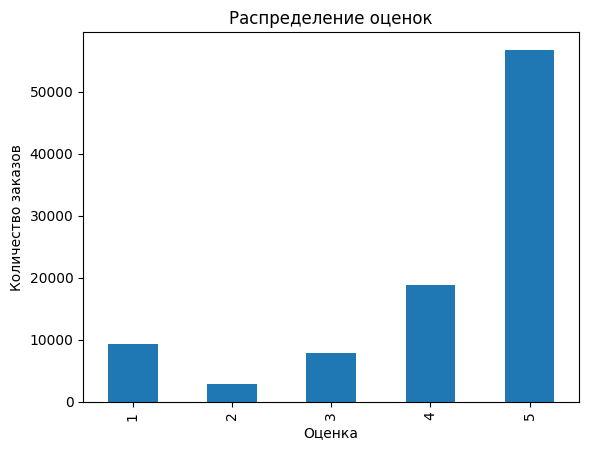

,proportion
review_score,
1,0.097576
2,0.030462
3,0.082611
4,0.197186
5,0.592165


In [82]:
# сколько заказов получили 1-5
df_features['review_score'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение оценок')
plt.xlabel('Оценка')
plt.ylabel('Количество заказов')
plt.show()

# в процентах
df_features['review_score'].value_counts(normalize=True).sort_index()


#### 60% заказов получили 5, и только 10% — минимальную оценку 1. Оценки 2-3 встречаются реже всего. Сильный дисбаланс классов, accuracy будет неинформативна.

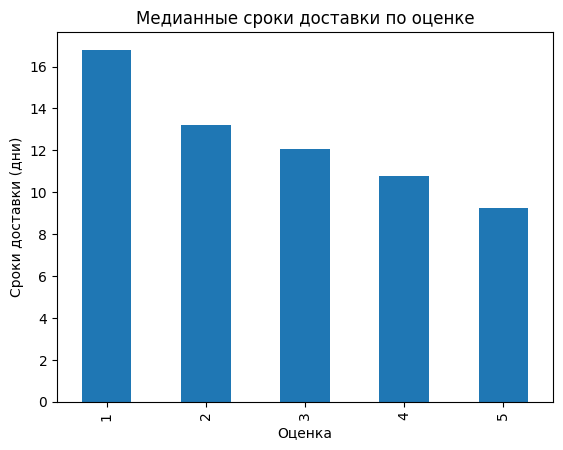

In [83]:
# медианное время доставки для каждой оценки
median_delivery_by_score = df_features.groupby('review_score')['delivery_days'].median()

median_delivery_by_score.plot(kind='bar')
plt.title('Медианные сроки доставки по оценке')
plt.xlabel('Оценка')
plt.ylabel('Сроки доставки (дни)')
plt.show()

#### Медианное время доставки для заказов с оценкой 1 заметно выше (около 17 дней), чем для оценки 5 (около 10 дней). Чем дольше доставка, тем ниже итоговая оценка.

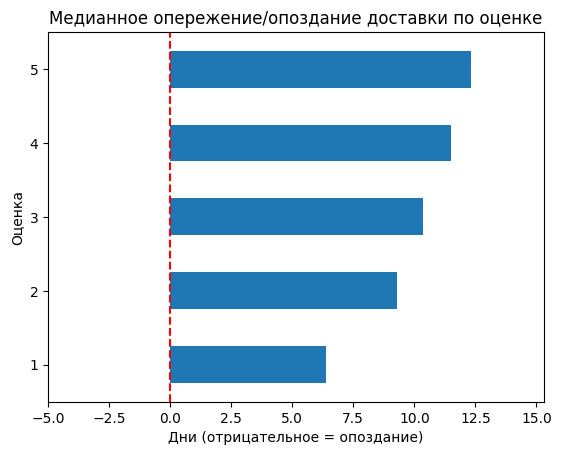

In [84]:
median_delivery_vs_estimate = df_features.groupby('review_score')['delivery_vs_estimate'].median()
median_delivery_vs_estimate.plot(kind='barh')
plt.axvline(0, color='red', linestyle='--')
plt.xlim(-5, median_delivery_vs_estimate.max() + 3)
plt.title('Медианное опережение/опоздание доставки по оценке')
plt.xlabel('Дни (отрицательное = опоздание)')
plt.ylabel('Оценка')
plt.show()

Медианный заказ доставляется раньше обещанного срока при любой оценке. Даже у заказов с оценкой 1 медиана составляет +6.5 дней (то есть в среднем такой заказ пришёл на 6.5 дней раньше даты, обещанной клиенту). Однако заметен чёткий растущий тренд: чем выше оценка, тем больше опережение срока (от 6.5 дней при оценке 1 до 12.5 дней при оценке 5). Это означает, что дело не столько в фактическом опоздании (медиана везде положительная), сколько в размере запаса времени: клиенты с оценкой 5 получают заказ с гораздо большим запасом от обещанной даты, а клиенты с оценкой 1 — с гораздо меньшим запасом, из-за чего у них выше шанс попасть в ту небольшую долю случаев, когда доставка всё же опаздывает.

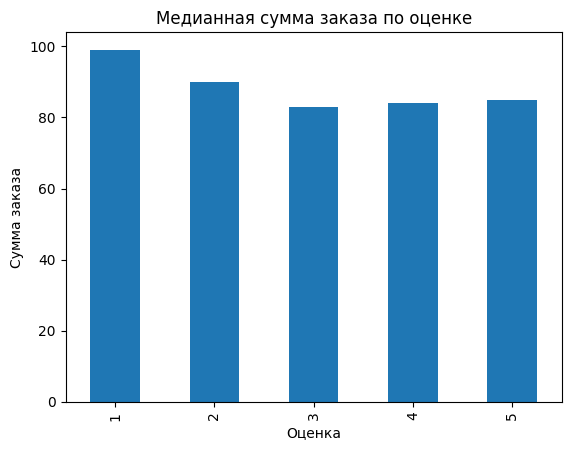

In [85]:
# медианная сумма заказа для каждой оценки
avg_price_by_score = df_features.groupby('review_score')['total_price'].median()

avg_price_by_score.plot(kind='bar')
plt.title('Медианная сумма заказа по оценке')
plt.xlabel('Оценка')
plt.ylabel('Сумма заказа')
plt.show()


#### Медианная сумма заказа относительно слабо меняется в зависимости от оценки — сумма заказа сама по себе не является сильным предиктором недовольства клиента.

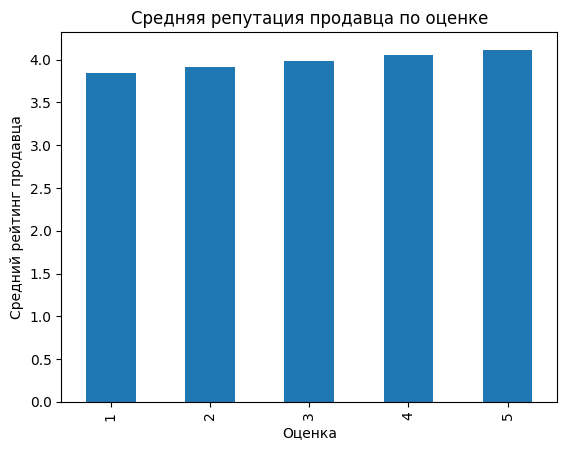

In [86]:
# средняя репутация продавца для каждой оценки заказа
avg_seller_by_score = df_features.groupby('review_score')['avg_seller_score'].mean()

avg_seller_by_score.plot(kind='bar')
plt.title('Средняя репутация продавца по оценке')
plt.xlabel('Оценка')
plt.ylabel('Средний рейтинг продавца')
plt.show()


#### Прослеживается небольшой но стабильный тренд: заказы с более высокой оценкой связаны с продавцами, у которых выше средняя историческая репутация.

In [87]:
# средняя оценка заказа в зависимости от количества использованных способов оплаты
df_features.groupby('payment_types_count')['review_score'].mean()


,review_score
payment_types_count,
1,4.156335
2,4.137182


Средняя оценка при одном и двух способах оплаты практически одинакова. Способ оплаты на удовлетворённость не влияет.

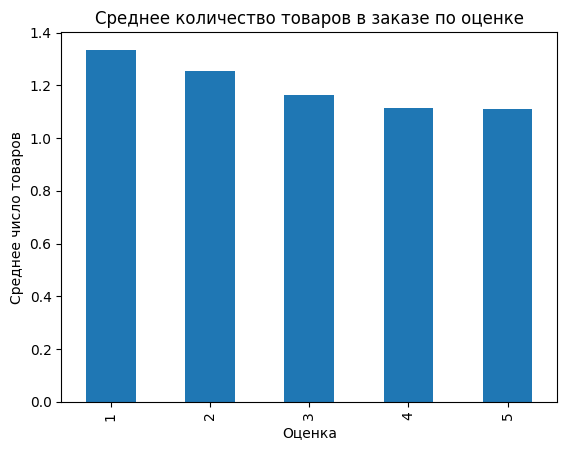

In [88]:
# среднее кол-во товаров в заказе
avg_items_by_score = df_features.groupby('review_score')['items_count'].mean()

avg_items_by_score.plot(kind='bar')
plt.title('Среднее количество товаров в заказе по оценке')
plt.xlabel('Оценка')
plt.ylabel('Среднее число товаров')
plt.show()

#### Чем больше товаров в заказе, тем ниже оценка. Заказы из нескольких товаров сложнее логистически и чаще вызывают недовольство.

### 6. Постановка задачи классификации

**Бинаризация целевой переменной.** Исходная оценка `review_score` (1–5) переводится в бинарный признак `is_bad_review`:

- **1–2 звезды → `is_bad_review = 1`** (негативный опыт клиента)
- **3–5 звёзд → `is_bad_review = 0`** (нейтральный/позитивный опыт)

После бинаризации доля негативного класса составляет **~12.8%** — выраженный дисбаланс классов, который учтён при обучении моделей (`class_weight='balanced'`) и выборе метрик (ROC-AUC, F1, precision/recall вместо accuracy).

In [89]:
# бинаризация
df_features['is_bad_review'] = (df_features['review_score'] <= 2).astype(int)
print(df_features['is_bad_review'].value_counts())
print(df_features['is_bad_review'].value_counts(normalize=True))

is_bad_review
0    83554
1    12269
Name: count, dtype: int64
is_bad_review
0    0.871962
1    0.128038
Name: proportion, dtype: float64


In [90]:
# проверка пропусков
df_features.isnull().sum()

,0
order_id,0
customer_id,0
review_score,0
delivery_days,0
delivery_vs_estimate,0
items_count,0
sellers_count,0
total_price,0
avg_item_price,0
total_freight,0


### 7. Обучение и сравнение моделей классификации (Logistic Regression, Random Forest)

##### 7.1 Logistic Regression

In [91]:
# Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# сборка признаков
feature_cols = [
    'delivery_days',
    'delivery_vs_estimate',
    'items_count',
    'sellers_count',
    'total_price',
    'avg_item_price',
    'total_freight',
    'payment_types_count',
    'total_payment',
    'avg_seller_score'
]

X = df_features[feature_cols]
y = df_features['is_bad_review']

# stratify для того чтобы сохранить пропорцию классов в обеих частях
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state=42, stratify=y)

# class_weight='balanced'для компенсации дисбаланса классов (13% плохих отзывов против 87% хороших)
model = LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')


              precision    recall  f1-score   support

           0       0.93      0.78      0.85     16711
           1       0.29      0.61      0.39      2454

    accuracy                           0.76     19165
   macro avg       0.61      0.70      0.62     19165
weighted avg       0.85      0.76      0.79     19165

ROC-AUC: 0.766


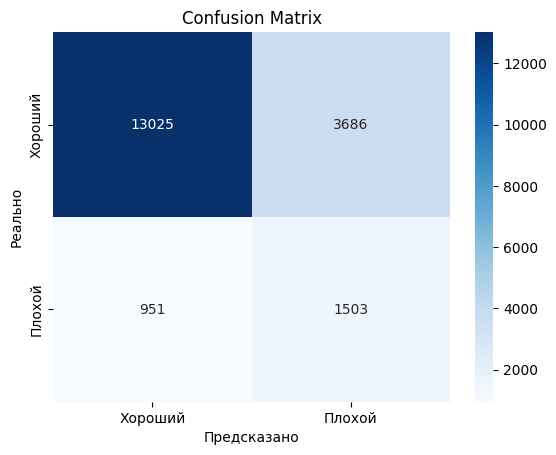

In [92]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Хороший', 'Плохой'], yticklabels=['Хороший', 'Плохой'])
plt.xlabel('Предсказано')
plt.ylabel('Реально')
plt.title('Confusion Matrix')
plt.show()

Модель находит 61% плохих отзывов, но часто ошибается на хороших заказах: большое число ложных срабатываний снижает precision до 0.29

In [93]:
importance = pd.DataFrame({'feature': feature_cols,'coefficient': model.coef_[0]}).sort_values('coefficient', key=abs, ascending=False)

importance

,feature,coefficient
3,sellers_count,1.729905
9,avg_seller_score,-1.412085
2,items_count,0.571144
0,delivery_days,0.059625
7,payment_types_count,-0.051352
1,delivery_vs_estimate,-0.031732
6,total_freight,-0.001743
4,total_price,0.001198
8,total_payment,-0.000714
5,avg_item_price,-0.000262


Признаки не масштабировались и имеют разные единицы измерения, поэтому их нельзя сравнивать между собой.

##### 7.2 Random Forest

In [94]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}')


              precision    recall  f1-score   support

           0       0.93      0.87      0.90     16711
           1       0.38      0.56      0.45      2454

    accuracy                           0.83     19165
   macro avg       0.66      0.71      0.67     19165
weighted avg       0.86      0.83      0.84     19165

ROC-AUC: 0.790


7.3 Logistic Regression vs Random Forest

In [95]:
# сводная таблица сравнения двух моделей
from sklearn.metrics import f1_score, recall_score, precision_score

comparison = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_rf)
    ],
    'Precision (плохой отзыв)': [
        precision_score(y_test, y_pred, pos_label=1),
        precision_score(y_test, y_pred_rf, pos_label=1)
    ],
    'Recall (плохой отзыв)': [
        recall_score(y_test, y_pred, pos_label=1),
        recall_score(y_test, y_pred_rf, pos_label=1)
    ],
    'F1 (плохой отзыв)': [
        f1_score(y_test, y_pred, pos_label=1),
        f1_score(y_test, y_pred_rf, pos_label=1)
    ]
})
comparison


,Модель,ROC-AUC,Precision (плохой отзыв),Recall (плохой отзыв),F1 (плохой отзыв)
0,Logistic Regression,0.765720,0.289651,0.612469,0.393301
1,Random Forest,0.789858,0.379862,0.561125,0.453035


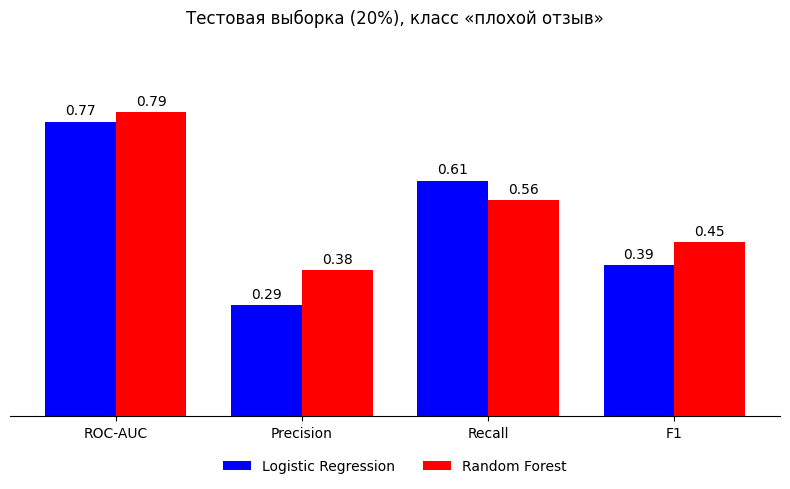

In [96]:
metrics = ['ROC-AUC', 'Precision', 'Recall', 'F1']
lr_scores = [roc_auc_score(y_test, y_proba),
             precision_score(y_test, y_pred),
             recall_score(y_test, y_pred),
             f1_score(y_test, y_pred)]
rf_scores = [roc_auc_score(y_test, y_proba_rf),
             precision_score(y_test, y_pred_rf),
             recall_score(y_test, y_pred_rf),
             f1_score(y_test, y_pred_rf)]

x = np.arange(len(metrics))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 5))
bars_lr = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='blue')
bars_rf = ax.bar(x + width/2, rf_scores, width, label='Random Forest', color='red')

ax.bar_label(bars_lr, fmt='%.2f', padding=3)
ax.bar_label(bars_rf, fmt='%.2f', padding=3)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title('Тестовая выборка (20%), класс «плохой отзыв»')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_yticks([])

plt.tight_layout()
plt.show()

#### Обе модели справляются с задачей, но по-разному расставляют приоритеты. **Random Forest** показывает более высокое качество в целом: ROC-AUC 0.79 против 0.77 у Logistic Regression, и F1-мера 0.45 против 0.39 для класса «плохой отзыв».

#### **Logistic Regression** лучше находит плохие отзывы (recall 0.61 против 0.56 у Random Forest). Однако эта чувствительность даётся ценой большего числа ложных срабатываний; модель чаще ошибочно помечает хорошие заказы как проблемные, что снижает precision.

#### Поскольку задача не просто найти как можно больше подозрительных заказов, а сделать это достаточно точно, чтобы результатам можно было доверять, **в качестве финальной модели выбран Random Forest** — он предлагает более сбалансированное соотношение точности и полноты.

### Важность признаков (Random Forest)

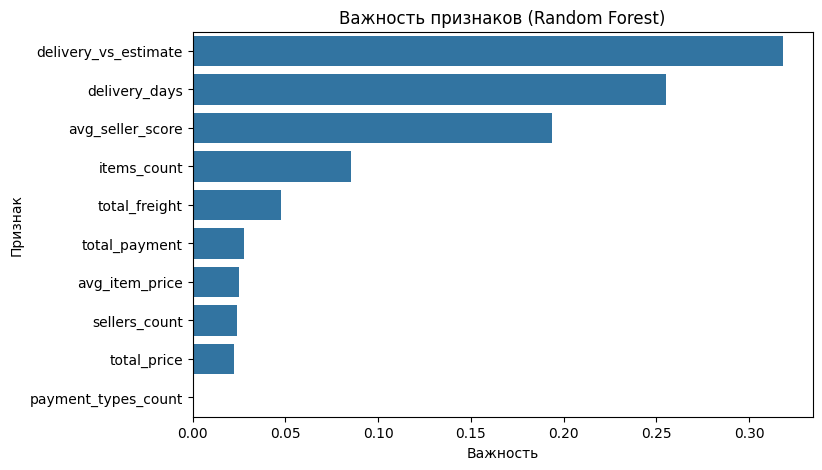

,feature,importance
1,delivery_vs_estimate,0.318425
0,delivery_days,0.255513
9,avg_seller_score,0.193724
2,items_count,0.085201
6,total_freight,0.047673
8,total_payment,0.027484
5,avg_item_price,0.025131
3,sellers_count,0.023737
4,total_price,0.022401
7,payment_types_count,0.000710


In [97]:
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=rf_importance, x='importance', y='feature')
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.show()

rf_importance

#### Random Forest показывает, что наиболее значимыми признаками являются **сроки доставки**: `delivery_vs_estimate` (0.32) — опоздание относительно обещанной даты — и `delivery_days` (0.26) — общая длительность доставки, вместе они формируют больше половины предсказательной силы модели. На третьем месте — `avg_seller_score` (0.19, репутация продавца). Остальные признаки, включая `sellers_count` (0.02) и финансовые показатели (сумма, способ оплаты), вносят заметно меньший вклад.

### 8. Итоговые выводы

**Ключевые находки:**

- Наиболее сильными предикторами низкой оценки оказались сроки доставки: запас до обещанной даты и общая длительность доставки дают вместе около 57% важности в модели Random Forest. На третьем месте — рейтинг продавца (19%).
- **Сумма заказа и способ оплаты** почти не влияют на итоговую оценку — клиенты Olist оценивают в первую очередь логистику и надёжность продавца, а не стоимость покупки.
- Распределение оценок сильно смещено в сторону положительных (60% — «5», 13% — «1–2»), что делает задачу классификации несбалансированной и требует соответствующих метрик и весов классов.

**Сравнение моделей:** Random Forest (ROC-AUC 0.79, F1 0.45) превзошёл Logistic Regression (ROC-AUC 0.77, F1 0.39) и выбран как финальная модель.

**Ограничения и допущения:**

- Признак репутации продавца (`avg_seller_score`) рассчитан по всем заказам продавца, **включая текущий**. Это создаёт небольшую утечку данных (data leakage). Для финальной модели репутацию следует считать только по заказам, предшествующим текущему по времени.
- Анализ ведётся на уровне заказа; для заказов с несколькими продавцами репутация усредняется, что может немного сглаживать эффект отдельного продавца (но такие заказы составляют небольшую долю датасета).
- Модель не использует текстовое содержание отзывов, что ограничивает потенциальное качество предсказания.
- Умеренное значение ROC-AUC (0.79) указывает на то, что часть факторов недовольства клиентов (качество товара, коммуникация с продавцом, индивидуальные ожидания) не отражена в имеющихся структурированных данных.

**Возможные направления развития:**

- Добавить NLP-анализ текста отзывов и описаний товаров.
- Учитывать сезонность (месяц/день недели заказа).
- Рассчитывать репутацию продавца только по историческим (более ранним) заказам, чтобы устранить утечку данных.
